In [2]:
import pandas as pd
import numpy as np

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_excel("DF_FINAL.xlsx")

df.head()

calles_base = [
        "Avenida Cardenal Herrera Oria",
        "Avenida Alfonso XIII",
        "Avenida Brasilia",
        "Avenida General Perón",
        "Calle Arturo Soria",
        "Calle Costa Rica",
        "Calle Génova",
        "Calle Hermanos García Noblejas",
        "Calle José Abascal",
        "Calle López de Hoyos",
        "Calle Príncipe de Vergara",
        "Calle Serrano",
        "Calle Velázquez",
        "Paseo de la Castellana"
]

calles_noreste = []

for base in calles_base:
    for col in df.columns:
        if base in col:
            calles_noreste.append(col)

L = 3  # número de lags

X = pd.DataFrame()

for street in calles_noreste:
    for lag in range(1, L + 1):
        X[f"{street}_t-{lag}"] = df[street].shift(lag)

# Variables externas reales
X["AEMET_tmed"] = df["AEMET_tmed"]
X["AEMET_prec"] = df["AEMET_prec"]
X["dia_semana"] = df["dia_semana"]
X["festivo"] = df["festivo"]

# Convertir variables categóricas a numéricas
X["dia_semana"] = X["dia_semana"].map({
    "lunes": 0,
    "martes": 1,
    "miércoles": 2,
    "jueves": 3,
    "viernes": 4,
    "sábado": 5,
    "domingo": 6
})

X["festivo"] = X["festivo"].map({
    "no": 0,
    "sí": 1
})


y_col = [col for col in df.columns if "Paseo de la Castellana" in col][0]
y = df[y_col]

# Limpiar NaNs
X = X.dropna()
y = y.loc[X.index]



In [4]:
# División temporal (80% train, 20% test)
split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

print(X_train.shape, X_test.shape)

(15376, 79) (3845, 79)


In [5]:
with pd.ExcelWriter("dataset_SVR_Castellana.xlsx") as writer:
    X_train.to_excel(writer, sheet_name="X_train")
    X_test.to_excel(writer, sheet_name="X_test")
    y_train.to_excel(writer, sheet_name="y_train")
    y_test.to_excel(writer, sheet_name="y_test")

In [6]:

model = SVR(
    kernel="rbf",
    C=10,
    epsilon=0.1,
    gamma="scale"
)

model.fit(X_train_scaled, y_train_scaled)

SVR(C=10)

In [7]:
y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

# Predicción próxima hora
X_next = X.iloc[[-1]]
X_next_scaled = scaler_X.transform(X_next)

y_next_scaled = model.predict(X_next_scaled)
y_next = scaler_y.inverse_transform(y_next_scaled.reshape(-1, 1)).ravel()

print("Predicción tráfico en Castellana (N-S) próxima hora:", y_next[0])

Predicción tráfico en Castellana (N-S) próxima hora: 429.10158384887416


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mask = y_test != 0
mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 81.37
RMSE: 113.68
MAPE: 15.91%


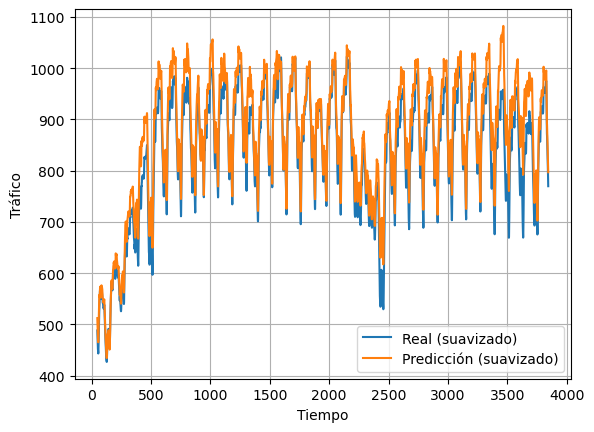

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

y_real_smooth = pd.Series(y_test.values).rolling(window=50).mean()
y_pred_smooth = pd.Series(y_pred).rolling(window=50).mean()

plt.figure()
plt.plot(y_real_smooth, label='Real (suavizado)')
plt.plot(y_pred_smooth, label='Predicción (suavizado)')

plt.legend()
plt.xlabel('Tiempo')
plt.ylabel('Tráfico')
plt.grid()

plt.show()

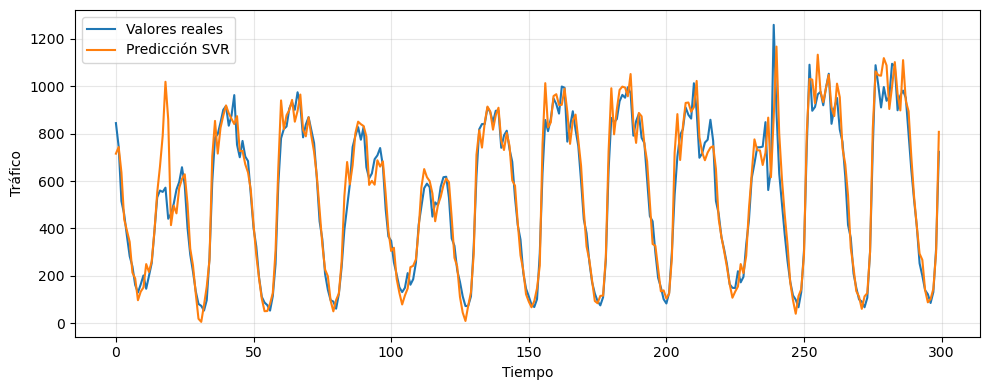

In [10]:
import matplotlib.pyplot as plt

n = 300  # número de puntos a mostrar

plt.figure(figsize=(10, 4))

plt.plot(y_test.values[:n], label='Valores reales', linewidth=1.5)
plt.plot(y_pred[:n], label='Predicción SVR', linewidth=1.5)

plt.xlabel('Tiempo')
plt.ylabel('Tráfico')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('real_vs_pred_svr_castellana.png', dpi=300, bbox_inches='tight')
plt.show()